In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import GEBCO
from stericheight.plotting_fns import PlottingFns
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean

from tqdm import tqdm
from gsw import density

ROOT = '/nfs/b0133/eejco/data/MEOP_2024/media/disk2/roquet/MEOP_public/MEOP-CTD_2024-03-08/'
FNAME_PROFILES = ROOT + 'list_profiles.csv'
FNAME_TAGS = ROOT + 'list_tags.csv'
FNAME_DEPLOYMENTS = ROOT + 'list_deployments.csv'


In [4]:
#define helper functions
def is_in(profile,extent):
        return ((profile.LATITUDE <= extent[3]) & 
                (profile.LATITUDE >= extent[2]) &
                (profile.LONGITUDE <= extent[1]) &
                (profile.LONGITUDE >= extent[0])
        )

In [34]:
# define study area
sabrina = [115,122,-70,-67.5]
wilkes = [100,136,-70,-60]
shackleton_sabrina = [95,122,-67.5,-64]
adelie = [120,170,-70,-64]
prydz = [50, 100,-70, -65]
vincennes_bay = [106,112,-67,-65]

In [22]:
elevation_ = GEBCO(coarsen_factor=10).ds.elevation

In [35]:
data_extent = vincennes_bay
map_extent = [103,116,-67,-63]

In [9]:
class Profile():
    def __init__(self,ds):
        self.latitude = ds.LATITUDE
        self.longitude = ds.LONGITUDE
        self.time = np.datetime64(ds.JULD.item().strftime('%Y-%m-%dT%H:%M:%S'))

        coords = {'pressure': ds.PRES_ADJUSTED}
        self.ds = xr.Dataset(
            {'temperature': xr.DataArray(ds.TEMP_ADJUSTED, coords=coords),
             'salinity': xr.DataArray(ds.PSAL_ADJUSTED, coords=coords)}
        )

In [23]:
# crop elevation
elevation = elevation_.sel(latitude = slice(map_extent[2], map_extent[3]), longitude = slice(map_extent[0],map_extent[1]))

In [11]:
# read deployments
deployments = pd.read_csv(FNAME_DEPLOYMENTS)

In [36]:
# read profiles and trim to latitudes we care about
profiles_ = pd.read_csv(FNAME_PROFILES)
profiles_ = profiles_[is_in(profiles_,[d + 5 for d in map_extent])] # the lat, lon on this list is the start point, so expand the area 


In [13]:
# define methods to retrieve info one each profile
deployment = lambda platform: str.split(platform,'-')[0]
country = lambda platform: str(deployments[deployments.DEPLOYMENT_CODE == deployment(platform)].COUNTRY.item())
folder = lambda platform: ROOT + country(platform) + '/DATA/'
filename = lambda platform: platform + '_all_prof.nc'

profile_codes=profiles_.SMRU_PLATFORM_CODE.unique()

flatten = lambda l: [item for sublist in l for item in sublist]   

In [37]:
# gather profiles in desired area, discard others
profiles = []
for pc in tqdm(profile_codes):
    fname = folder(pc)+filename(pc)
    ds = xr.open_dataset(fname)

    in_area = is_in(ds,data_extent)

    if any(in_area):
        for n in ds.N_PROF.where(in_area,drop=True):
            profiles.append(Profile(ds.sel(N_PROF=int(n))))
            # profile = ds.sel(N_PROF=n)
            # if is_in(profile,data_extent):
            #     entry = build_entry(profile,fname)
            #     if len(entry)>0:
            #         profile_dicts.append(entry)

  0%|          | 0/47 [00:00<?, ?it/s]

100%|██████████| 47/47 [00:06<00:00,  7.52it/s]


In [38]:
lats = [p.latitude for p in profiles]
lons = [p.longitude for p in profiles]
sst = [p.ds.temperature.isel(N_LEVELS=0) for p in profiles]
times = [p.time for p in profiles]

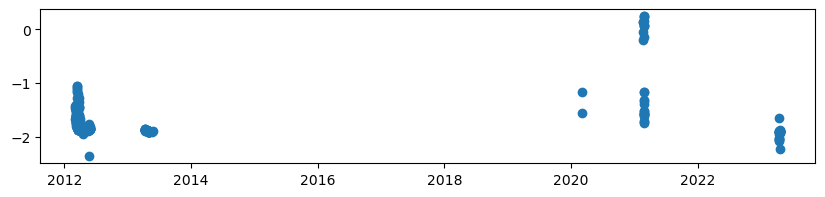

In [39]:
fig,ax = plt.subplots(figsize=(10,2))
ax.scatter(times,sst)

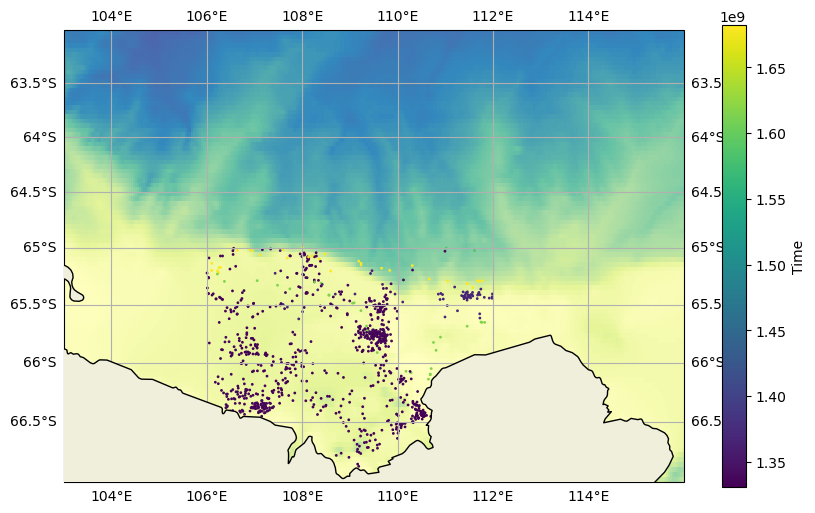

In [40]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax=ax,da=elevation,extent=map_extent)
im=ax.scatter(lons, lats, [1 for t in times], times, transform=ccrs.PlateCarree())
plt.colorbar(im, label='Time')

In [47]:
len(profile_list)

15